In [1]:
# ─── 0. Kurulum ve Veri Yolu (Colab/Drive Uyumlu) ───
# --- GOOGLE COLAB + DRIVE KULLANIYORSAN bu üç satırın başındaki # işaretlerini sil: ---
# from google.colab import drive
# drive.mount('/content/drive')
# VERI_KLASORU = "/content/drive/MyDrive/SoftITO"   # csv dosyasını Drive'da koyduğun klasör

# Bilgisayarda ya da dosya notebook ile aynı klasördeyse bu yeterli:
VERI_KLASORU = "."


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

plt.rcParams['figure.figsize'] = (10, 6)
sns.set_style('whitegrid')

import warnings
warnings.filterwarnings('ignore')

In [3]:
# ─── 1. Veriyi Yükleme ve Keşif ───
df = pd.read_csv(f"{VERI_KLASORU}/mutluluk_2015_2019_temiz.csv")
print(df.shape)
df.head()

(782, 10)


,Yil,Ulke,Sira,Skor,GSYH,Sosyal_Destek,Saglik,Ozgurluk,Comertlik,Yolsuzluk_Algisi
0,2015,Switzerland,1,7.587,1.39651,1.34951,0.94143,0.66557,0.29678,0.41978
1,2015,Iceland,2,7.561,1.30232,1.40223,0.94784,0.62877,0.43630,0.14145
2,2015,Denmark,3,7.527,1.32548,1.36058,0.87464,0.64938,0.34139,0.48357
3,2015,Norway,4,7.522,1.45900,1.33095,0.88521,0.66973,0.34699,0.36503
4,2015,Canada,5,7.427,1.32629,1.32261,0.90563,0.63297,0.45811,0.32957


In [4]:
# Veri temizleme pratiğinden geldiği için tertemiz olmalı — yine de kontrol ediyoruz
print("Eksik değer sayısı:\n", df.isnull().sum())
print()
df.describe().round(3)

Eksik değer sayısı:
 Yil                 0
Ulke                0
Sira                0
Skor                0
GSYH                0
Sosyal_Destek       0
Saglik              0
Ozgurluk            0
Comertlik           0
Yolsuzluk_Algisi    0
dtype: int64



,Yil,Sira,Skor,GSYH,Sosyal_Destek,Saglik,Ozgurluk,Comertlik,Yolsuzluk_Algisi
count,782.000,782.000,782.000,782.000,782.000,782.000,782.000,782.000,782.000
mean,2016.994,78.698,5.379,0.916,1.078,0.612,0.411,0.219,0.125
std,1.417,45.182,1.127,0.407,0.330,0.248,0.153,0.122,0.106
min,2015.000,1.000,2.693,0.000,0.000,0.000,0.000,0.000,0.000
25%,2016.000,40.000,4.510,0.606,0.869,0.440,0.310,0.130,0.054
50%,2017.000,79.000,5.322,0.982,1.125,0.647,0.431,0.202,0.091
75%,2018.000,118.000,6.190,1.236,1.327,0.808,0.531,0.279,0.156
max,2019.000,158.000,7.769,2.096,1.644,1.141,0.724,0.838,0.552


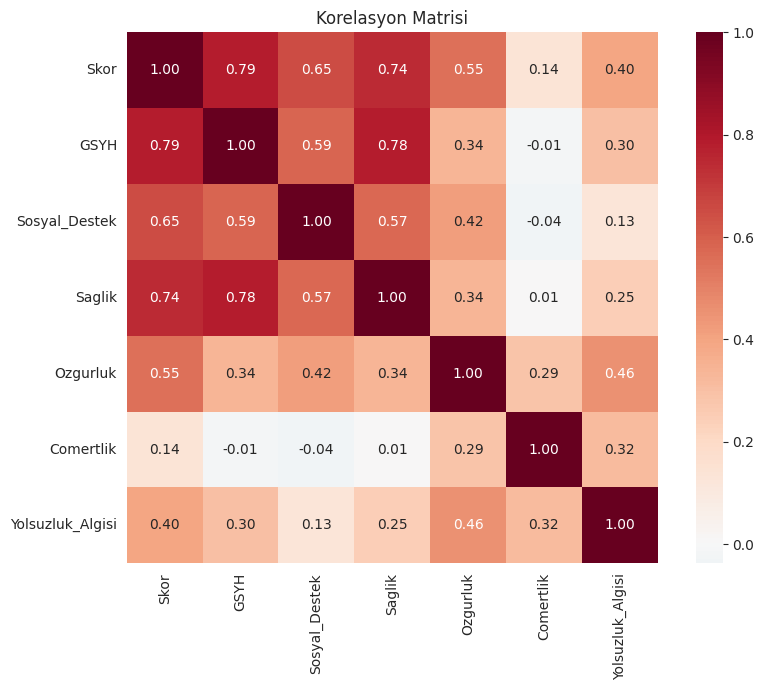

In [5]:
# ─── 2. Keşifçi Veri Analizi (EDA) ───
# Sayısal sütunların korelasyon matrisi (Yil ve Sira'yı özellik olarak kullanmayacağız;
# Sira zaten Skor'dan türetilmiş bir sıralamadır - modele koymak "cevabı sızdırmak" olurdu!)
ozellikler = ["GSYH", "Sosyal_Destek", "Saglik", "Ozgurluk", "Comertlik", "Yolsuzluk_Algisi"]
korelasyon = df[["Skor"] + ozellikler].corr()

plt.figure(figsize=(9, 7))
sns.heatmap(korelasyon, annot=True, fmt=".2f", cmap="RdBu_r", center=0, square=True)
plt.title("Korelasyon Matrisi")
plt.tight_layout()
plt.show()

In [6]:
# Hedef değişken Skor ile korelasyonları büyükten küçüğe sıralayalım
skor_kor = korelasyon["Skor"].drop("Skor").sort_values(ascending=False)
print("Skor ile korelasyonlar:")
print(skor_kor.round(3))

Skor ile korelasyonlar:
GSYH                0.789
Saglik              0.742
Sosyal_Destek       0.649
Ozgurluk            0.551
Yolsuzluk_Algisi    0.397
Comertlik           0.138
Name: Skor, dtype: float64


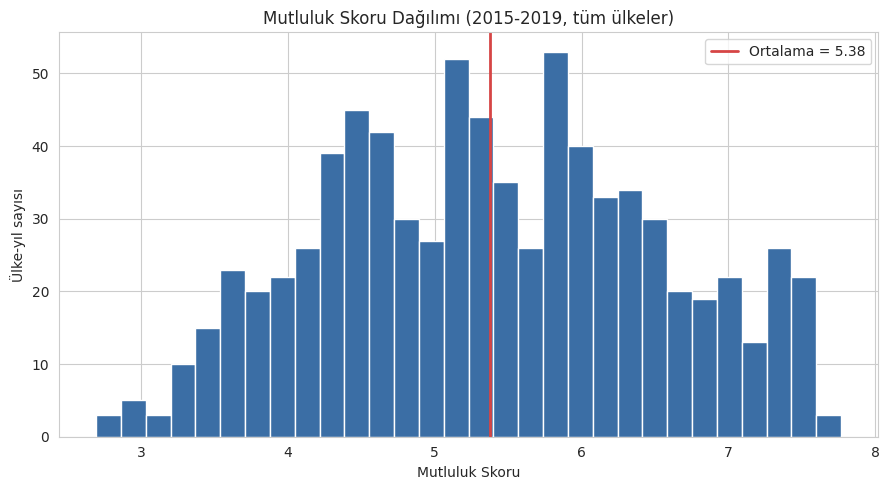

In [7]:
# Hedef değişkenin dağılımı (dersteki gibi)
plt.figure(figsize=(9, 5))
plt.hist(df["Skor"], bins=30, color="#3b6ea5", edgecolor="white")
plt.axvline(df["Skor"].mean(), color="#d64545", linewidth=2,
            label=f"Ortalama = {df['Skor'].mean():.2f}")
plt.xlabel("Mutluluk Skoru")
plt.ylabel("Ülke-yıl sayısı")
plt.title("Mutluluk Skoru Dağılımı (2015-2019, tüm ülkeler)")
plt.legend()
plt.tight_layout()
plt.show()

In [8]:
# ─── 3. Basit Doğrusal Regresyon: GSYH → Skor ───
# Basit regresyon için değişkenler
X_simple = df[["GSYH"]].values
y = df["Skor"].values

# Eğitim ve test setlerine ayır (%80 eğitim, %20 test) — dersteki gibi random_state=42
X_train, X_test, y_train, y_test = train_test_split(X_simple, y, test_size=0.2, random_state=42)

print(f"Eğitim seti boyutu: {X_train.shape[0]}")
print(f"Test seti boyutu  : {X_test.shape[0]}")

Eğitim seti boyutu: 625
Test seti boyutu  : 157


In [9]:
# Modeli oluştur ve eğit
model_simple = LinearRegression()
model_simple.fit(X_train, y_train)

print(f"b0 (intercept) = {model_simple.intercept_:.3f}")
print(f"b1 (GSYH katsayısı) = {model_simple.coef_[0]:.3f}")
print(f"Denklem: Skor = {model_simple.intercept_:.2f} + {model_simple.coef_[0]:.2f} · GSYH")

b0 (intercept) = 3.405
b1 (GSYH katsayısı) = 2.164
Denklem: Skor = 3.40 + 2.16 · GSYH


In [10]:
# Test seti üzerinde performans metrikleri (dersteki üçlü: R², MAE, RMSE)
y_pred_s = model_simple.predict(X_test)

r2_s   = r2_score(y_test, y_pred_s)
mae_s  = mean_absolute_error(y_test, y_pred_s)
rmse_s = np.sqrt(mean_squared_error(y_test, y_pred_s))

print(f"R²   = {r2_s:.4f}")
print(f"MAE  = {mae_s:.4f}  (ortalama mutlak hata, skor puanı cinsinden)")
print(f"RMSE = {rmse_s:.4f}")

R²   = 0.6188
MAE  = 0.5487  (ortalama mutlak hata, skor puanı cinsinden)
RMSE = 0.6809


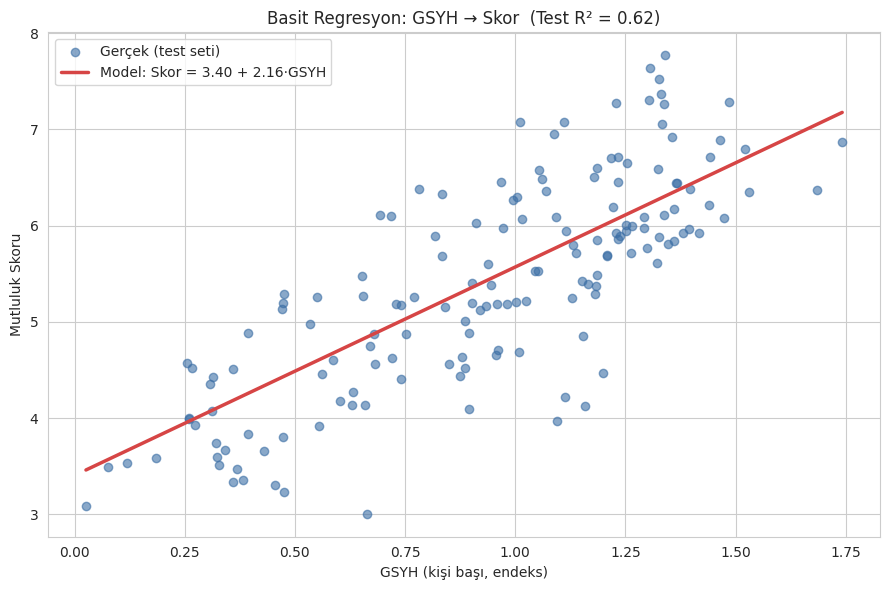

In [11]:
# Görselleştirme: regresyon doğrusu + test noktaları
plt.figure(figsize=(9, 6))
plt.scatter(X_test, y_test, alpha=0.6, color="#3b6ea5", label="Gerçek (test seti)")
siralama = X_test.ravel().argsort()
plt.plot(X_test.ravel()[siralama], y_pred_s[siralama], color="#d64545", linewidth=2.5,
         label=f"Model: Skor = {model_simple.intercept_:.2f} + {model_simple.coef_[0]:.2f}·GSYH")
plt.xlabel("GSYH (kişi başı, endeks)")
plt.ylabel("Mutluluk Skoru")
plt.title(f"Basit Regresyon: GSYH → Skor  (Test R² = {r2_s:.2f})")
plt.legend()
plt.tight_layout()
plt.show()

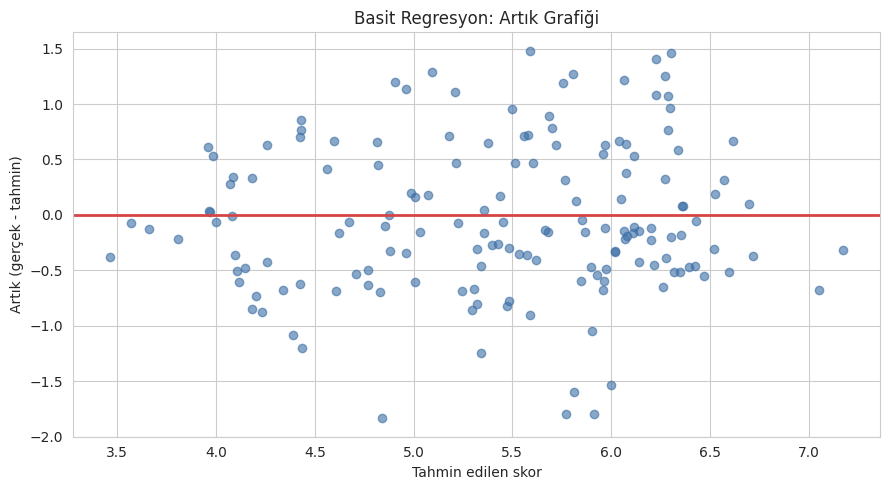

In [12]:
# Artık (residual) analizi
resid = y_test - y_pred_s
plt.figure(figsize=(9, 5))
plt.scatter(y_pred_s, resid, alpha=0.6, color="#3b6ea5")
plt.axhline(0, color="#d64545", linewidth=2)
plt.xlabel("Tahmin edilen skor")
plt.ylabel("Artık (gerçek - tahmin)")
plt.title("Basit Regresyon: Artık Grafiği")
plt.tight_layout()
plt.show()

In [13]:
# ─── 4. Çoklu Doğrusal Regresyon ───
# Korelasyonu 0.35'ten yüksek özellikleri seçelim
secilen = skor_kor[abs(skor_kor) > 0.35].index.tolist()
print("Seçilen özellikler:", secilen)

Seçilen özellikler: ['GSYH', 'Saglik', 'Sosyal_Destek', 'Ozgurluk', 'Yolsuzluk_Algisi']


In [14]:
# Çoklu regresyon için veri hazırlığı
X_multi = df[secilen].values
X_train_m, X_test_m, y_train_m, y_test_m = train_test_split(X_multi, y, test_size=0.2, random_state=42)

# Modeli oluştur ve eğit
model_multi = LinearRegression()
model_multi.fit(X_train_m, y_train_m)

print("b0 (intercept):", round(model_multi.intercept_, 3))
for ozellik, katsayi in zip(secilen, model_multi.coef_):
    print(f"  {ozellik:<18} katsayı: {katsayi:>7.3f}")

b0 (intercept): 2.276
  GSYH               katsayı:   1.040
  Saglik             katsayı:   1.043
  Sosyal_Destek      katsayı:   0.645
  Ozgurluk           katsayı:   1.577
  Yolsuzluk_Algisi   katsayı:   1.349


In [15]:
# Çoklu model performansı (test seti)
y_pred_m = model_multi.predict(X_test_m)

r2_m   = r2_score(y_test_m, y_pred_m)
mae_m  = mean_absolute_error(y_test_m, y_pred_m)
rmse_m = np.sqrt(mean_squared_error(y_test_m, y_pred_m))

print(f"R²   = {r2_m:.4f}")
print(f"MAE  = {mae_m:.4f}")
print(f"RMSE = {rmse_m:.4f}")

R²   = 0.7206
MAE  = 0.4482
RMSE = 0.5830


In [16]:
# ─── 4.2 İki Modelin Karşılaştırılması ───
karsilastirma = pd.DataFrame({
    "Model": ["Basit (sadece GSYH)", f"Çoklu ({len(secilen)} özellik)"],
    "R2":   [round(r2_s, 4),  round(r2_m, 4)],
    "MAE":  [round(mae_s, 4), round(mae_m, 4)],
    "RMSE": [round(rmse_s, 4), round(rmse_m, 4)],
})
karsilastirma

,Model,R2,MAE,RMSE
0,Basit (sadece GSYH),0.6188,0.5487,0.6809
1,Çoklu (5 özellik),0.7206,0.4482,0.5830


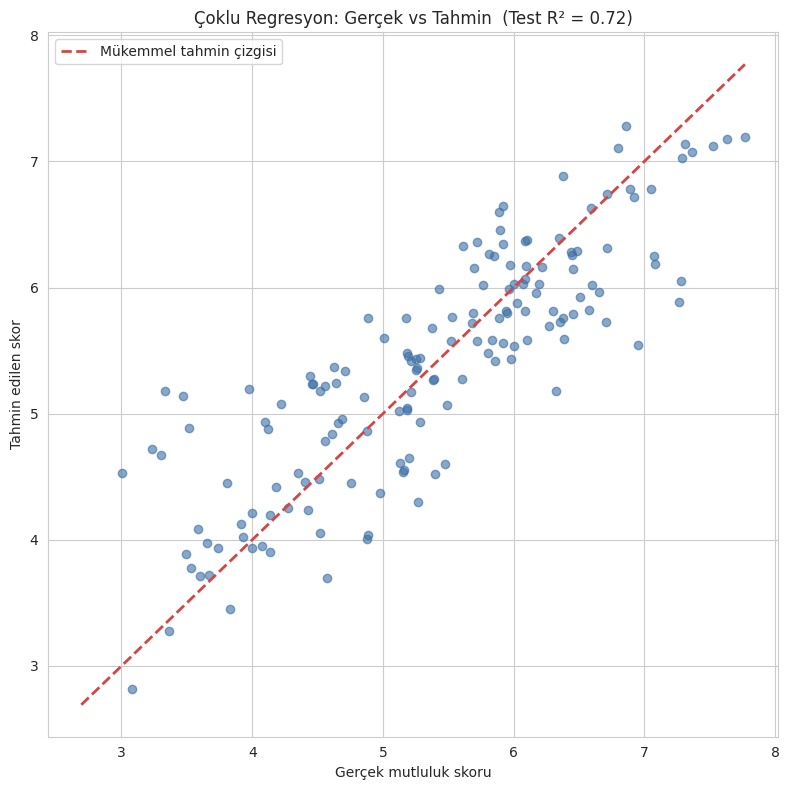

In [17]:
# Gerçek vs Tahmin karşılaştırması (çoklu regresyon) — dersteki 45 derece çizgili grafik
plt.figure(figsize=(8, 8))
plt.scatter(y_test_m, y_pred_m, alpha=0.6, color="#3b6ea5")
kenar = [y.min(), y.max()]
plt.plot(kenar, kenar, color="#d64545", linewidth=2, linestyle="--", label="Mükemmel tahmin çizgisi")
plt.xlabel("Gerçek mutluluk skoru")
plt.ylabel("Tahmin edilen skor")
plt.title(f"Çoklu Regresyon: Gerçek vs Tahmin  (Test R² = {r2_m:.2f})")
plt.legend()
plt.tight_layout()
plt.show()

         Ozellik  Katsayi  Mutlak_Katsayi
        Ozgurluk    1.577           1.577
Yolsuzluk_Algisi    1.349           1.349
          Saglik    1.043           1.043
            GSYH    1.040           1.040
   Sosyal_Destek    0.645           0.645


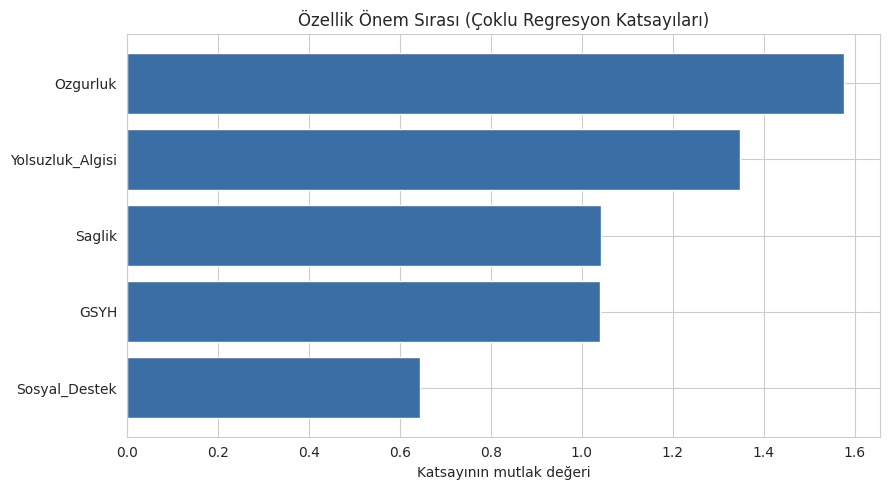

In [18]:
# ─── 4.3 Özellik Önem Sırası ───
onem = pd.DataFrame({
    "Ozellik": secilen,
    "Katsayi": model_multi.coef_.round(3),
    "Mutlak_Katsayi": np.abs(model_multi.coef_).round(3),
}).sort_values("Mutlak_Katsayi", ascending=False).reset_index(drop=True)

print(onem.to_string(index=False))

plt.figure(figsize=(9, 5))
plt.barh(onem["Ozellik"][::-1], onem["Mutlak_Katsayi"][::-1], color="#3b6ea5")
plt.xlabel("Katsayının mutlak değeri")
plt.title("Özellik Önem Sırası (Çoklu Regresyon Katsayıları)")
plt.tight_layout()
plt.show()

In [19]:
# ─── 5. Sonuç ve Yorumlar ───
print("=" * 60)
print("MODEL ÖZETİ")
print("=" * 60)
print(f"Basit model  (GSYH)              : Test R² = {r2_s:.3f}, MAE = {mae_s:.3f}")
print(f"Çoklu model  ({len(secilen)} özellik)          : Test R² = {r2_m:.3f}, MAE = {mae_m:.3f}")
print()
iyilesme = (r2_m - r2_s) / r2_s * 100
print(f"Çoklu model, basit modele göre R²'yi %{iyilesme:.1f} iyileştirdi.")
print(f"Ortalama tahmin hatası (MAE) {mae_s:.2f} puandan {mae_m:.2f} puana düştü.")

MODEL ÖZETİ
Basit model  (GSYH)              : Test R² = 0.619, MAE = 0.549
Çoklu model  (5 özellik)          : Test R² = 0.721, MAE = 0.448

Çoklu model, basit modele göre R²'yi %16.5 iyileştirdi.
Ortalama tahmin hatası (MAE) 0.55 puandan 0.45 puana düştü.
